# Laboratorium 4: Algorytmy grupowania danych (k-means i DBSCAN)


In [60]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, rand_score,
)
from sklearn.metrics.cluster import contingency_matrix

# warnings.filterwarnings('ignore', category=UserWarning)
# warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')


## 0. Funkcje pomocnicze

Wszystkie miary i pomoce wizualne w jednym miejscu — używane w całym notebooku.


In [61]:
def purity(y_true, y_pred):
    cm = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)


def cluster_metrics(X, y_true, labels):
    mask = labels != -1
    uniq = set(labels[mask]) if mask.any() else set()
    n_clusters = len(uniq)
    n_noise = int((labels == -1).sum())
    res = {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
    }
    if n_clusters >= 2 and mask.sum() > n_clusters:
        res['silhouette'] = silhouette_score(X[mask], labels[mask])
        res['davies_bouldin'] = davies_bouldin_score(X[mask], labels[mask])
    else:
        res['silhouette'] = np.nan
        res['davies_bouldin'] = np.nan
    if y_true is not None:
        res['ARI'] = adjusted_rand_score(y_true, labels)
        res['purity'] = purity(y_true, labels)
    return res


def plot_clusters_pca(X_scaled, labels, y_true, title, ax=None, pca=None):
    if pca is None:
        pca = PCA(n_components=2).fit(X_scaled)
    Z = pca.transform(X_scaled)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '*']
    classes = sorted(np.unique(y_true)) if y_true is not None else [0]
    uniq = sorted(set(labels))
    palette = plt.cm.tab10(np.linspace(0, 1, max(len(uniq), 3)))
    color_map = {lbl: ('lightgray' if lbl == -1 else palette[i % 10]) for i, lbl in enumerate(uniq)}
    for cls_i, cls in enumerate(classes):
        m = markers[cls_i % len(markers)]
        for lbl in uniq:
            sel = (labels == lbl) & ((y_true == cls) if y_true is not None else np.ones_like(labels, bool))
            if sel.any():
                ax.scatter(Z[sel, 0], Z[sel, 1],
                           c=[color_map[lbl]], marker=('x' if lbl == -1 else m),
                           s=40, edgecolors='k', linewidths=0.3, alpha=0.85)
    handles = [
        plt.Line2D([0], [0], marker=markers[i % len(markers)], color='w',
                   markerfacecolor='gray', markeredgecolor='k',
                   markeredgewidth=0.5, markersize=7, label=f'klasa {cls}')
        for i, cls in enumerate(classes)
    ]
    ax.legend(handles=handles, title='klasa GT', fontsize=8, title_fontsize=8,
              loc='best', framealpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    return pca

def class_histogram(y, title):
    vc = pd.Series(y).value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(vc)))
    bars = ax.bar(vc.index.astype(str), vc.values, color=colors, edgecolor='k')
    for b, v in zip(bars, vc.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.3, str(v), ha='center', fontsize=9)
    ax.set_title(title)
    ax.set_ylabel('liczność')
    plt.tight_layout()
    plt.show()


def plot_contingency(y_true, labels, title):
    cm = contingency_matrix(y_true, labels)
    cluster_labels = sorted(set(labels))
    class_labels = sorted(set(y_true))
    fig, ax = plt.subplots(figsize=(max(6, len(cluster_labels)), max(4, len(class_labels))))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[f'kl.{i}' for i in cluster_labels],
                yticklabels=class_labels)
    ax.set_xlabel('klaster')
    ax.set_ylabel('klasa GT')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## 1. Sanity check — IRIS


IRIS: (150, 4), klasy: [0 1 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.0000,150.0000,150.0000,150.0000
mean,5.8430,3.0570,3.7580,1.1990
std,0.8280,0.4360,1.7650,0.7620
min,4.3000,2.0000,1.0000,0.1000
25%,5.1000,2.8000,1.6000,0.3000
50%,5.8000,3.0000,4.3500,1.3000
75%,6.4000,3.3000,5.1000,1.8000
max,7.9000,4.4000,6.9000,2.5000


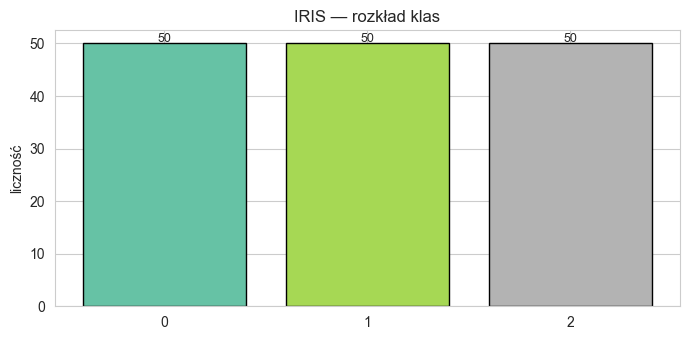

In [62]:
iris = load_iris()
X_iris_raw = iris.data
y_iris = iris.target
feat_iris = iris.feature_names

X_iris = StandardScaler().fit_transform(X_iris_raw)
print(f'IRIS: {X_iris.shape}, klasy: {np.unique(y_iris)}')
display(pd.DataFrame(X_iris_raw, columns=feat_iris).describe().round(3))
class_histogram(y_iris, 'IRIS — rozkład klas')


Sanity-check KMeans(k=3) na IRIS:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
0,3,0,0.4599,0.8336,0.6201,0.8333


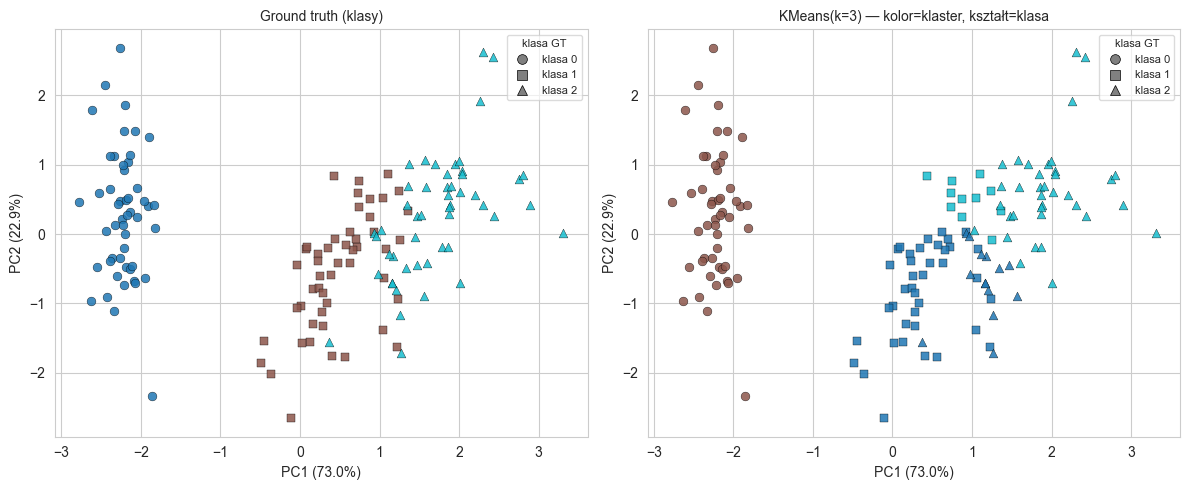

In [63]:
km_iris = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_iris)
m = cluster_metrics(X_iris, y_iris, km_iris.labels_)
print('Sanity-check KMeans(k=3) na IRIS:')
display(pd.DataFrame([m]).round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_clusters_pca(X_iris, y_iris, y_iris, 'Ground truth (klasy)', ax=axes[0])
plot_clusters_pca(X_iris, km_iris.labels_, y_iris, 'KMeans(k=3) — kolor=klaster, kształt=klasa', ax=axes[1])
plt.tight_layout()
plt.show()


## 2. Wczytanie zbiorów SEEDS i GLASS


SEEDS: X=(210, 7), klasy=[1 2 3]


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length
count,210.0000,210.0000,210.0000,210.0000,210.0000,210.0000,210.0000
mean,14.8480,14.5590,0.8710,5.6290,3.2590,3.7000,5.4080
std,2.9100,1.3060,0.0240,0.4430,0.3780,1.5040,0.4910
min,10.5900,12.4100,0.8080,4.8990,2.6300,0.7650,4.5190
25%,12.2700,13.4500,0.8570,5.2620,2.9440,2.5620,5.0450
50%,14.3550,14.3200,0.8730,5.5240,3.2370,3.5990,5.2230
75%,17.3050,15.7150,0.8880,5.9800,3.5620,4.7690,5.8770
max,21.1800,17.2500,0.9180,6.6750,4.0330,8.4560,6.5500


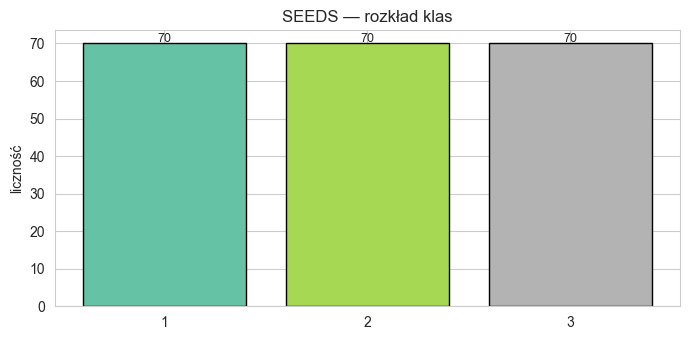

In [64]:
import os, urllib.request
SEEDS_PATH = 'data/seeds_dataset.txt'
SEEDS_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'
if not os.path.exists(SEEDS_PATH):
    os.makedirs(os.path.dirname(SEEDS_PATH), exist_ok=True)
    urllib.request.urlretrieve(SEEDS_URL, SEEDS_PATH)
feat_seeds = ['area', 'perimeter', 'compactness', 'kernel_length',
              'kernel_width', 'asymmetry', 'groove_length']
seeds_df = pd.read_csv(SEEDS_PATH, sep=r'\s+', header=None,
                       names=feat_seeds + ['class'])
X_seeds_raw = seeds_df[feat_seeds].values
y_seeds = seeds_df['class'].values
print(f'SEEDS: X={X_seeds_raw.shape}, klasy={np.unique(y_seeds)}')
display(seeds_df[feat_seeds].describe().round(3))
class_histogram(y_seeds, 'SEEDS — rozkład klas')


GLASS: X=(214, 9), klasy=[1 2 3 5 6 7]


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000,214.0000
mean,1.5180,13.4080,2.6850,1.4450,72.6510,0.4970,8.9570,0.1750,0.0570
std,0.0030,0.8170,1.4420,0.4990,0.7750,0.6520,1.4230,0.4970,0.0970
min,1.5110,10.7300,0.0000,0.2900,69.8100,0.0000,5.4300,0.0000,0.0000
25%,1.5170,12.9080,2.1150,1.1900,72.2800,0.1220,8.2400,0.0000,0.0000
50%,1.5180,13.3000,3.4800,1.3600,72.7900,0.5550,8.6000,0.0000,0.0000
75%,1.5190,13.8250,3.6000,1.6300,73.0880,0.6100,9.1720,0.0000,0.1000
max,1.5340,17.3800,4.4900,3.5000,75.4100,6.2100,16.1900,3.1500,0.5100


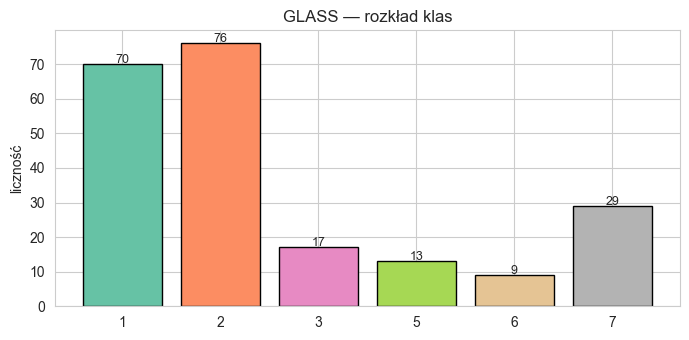

In [65]:
glass = fetch_ucirepo(id=42)
X_glass_raw = glass.data.features.values
y_glass = glass.data.targets.values.ravel()
feat_glass = list(glass.data.features.columns)
print(f'GLASS: X={X_glass_raw.shape}, klasy={np.unique(y_glass)}')
display(glass.data.features.describe().round(3))
class_histogram(y_glass, 'GLASS — rozkład klas')


In [66]:
X_seeds = StandardScaler().fit_transform(X_seeds_raw)
X_glass = StandardScaler().fit_transform(X_glass_raw)

DATASETS = {
    'SEEDS': (X_seeds, y_seeds, len(np.unique(y_seeds))),
    'GLASS': (X_glass, y_glass, len(np.unique(y_glass))),
}
for name, (X, y, k) in DATASETS.items():
    print(f'{name}: n={X.shape[0]}, d={X.shape[1]}, #klas={k}')


SEEDS: n=210, d=7, #klas=3
GLASS: n=214, d=9, #klas=6


### Wybór k dla k-means — wstępna decyzja


In [67]:
k_best_seeds = 3
k_best_glass = 6
print(f'k_best: SEEDS={k_best_seeds}, GLASS={k_best_glass}')


k_best: SEEDS=3, GLASS=6


## 3. K-means — sweep hiperparametrów


### 3.1 `n_clusters` — liczba klastrów


IRIS — sweep n_clusters:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,inertia
k,,,,,,,
2,2,0,0.5818,0.5933,0.5681,0.6667,222.3617
3,3,0,0.4599,0.8336,0.6201,0.8333,139.8205
4,4,0,0.3869,0.8698,0.4728,0.8333,114.0925
5,5,0,0.3455,0.9452,0.4205,0.8333,90.8076
6,6,0,0.3257,1.0519,0.3563,0.8267,80.0225
7,7,0,0.3323,1.0654,0.4088,0.9200,71.6126
8,8,0,0.3449,0.8870,0.3136,0.8267,62.8661
9,9,0,0.3400,0.9608,0.3768,0.9600,55.5171
10,10,0,0.3486,0.8959,0.3323,0.9467,47.2637


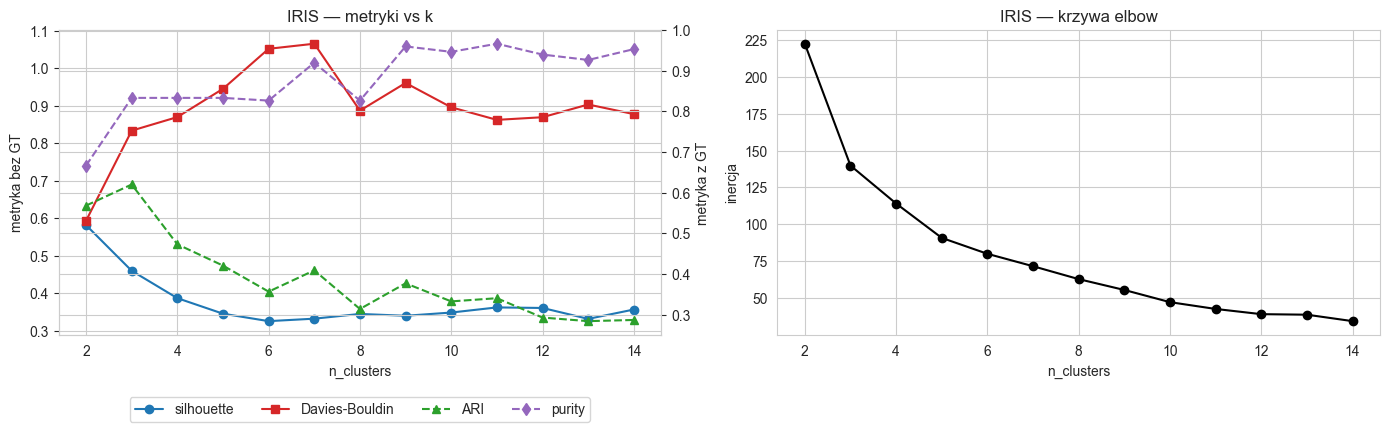

interactive(children=(IntSlider(value=3, continuous_update=False, description='k:', max=14, min=2), Output()),…

In [68]:
def sweep_n_clusters(X, y, k_range, n_init=10):
    rows = []
    models = {}
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=0).fit(X)
        m = cluster_metrics(X, y, km.labels_)
        m['k'] = k
        m['inertia'] = km.inertia_
        rows.append(m)
        models[k] = km
    df = pd.DataFrame(rows).set_index('k')
    return df, models


k_range = list(range(2, 15))
res_iris_k, models_iris_k = sweep_n_clusters(X_iris, y_iris, k_range)
print('IRIS — sweep n_clusters:')
display(res_iris_k.round(4))

def plot_k_sweep(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    ax = axes[0]
    lines = []
    lines += ax.plot(df.index, df['silhouette'], 'o-', label='silhouette', color='tab:blue')
    lines += ax.plot(df.index, df['davies_bouldin'], 's-', label='Davies-Bouldin', color='tab:red')
    ax.set_xlabel('n_clusters'); ax.set_ylabel('metryka bez GT')
    if 'ARI' in df.columns:
        ax2 = ax.twinx()
        lines += ax2.plot(df.index, df['ARI'], '^--', label='ARI', color='tab:green')
        lines += ax2.plot(df.index, df['purity'], 'd--', label='purity', color='tab:purple')
        ax2.set_ylabel('metryka z GT')
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=4, frameon=True)
    axes[0].set_title(f'{title} — metryki vs k')
    axes[1].plot(df.index, df['inertia'], 'o-', color='black')
    axes[1].set_xlabel('n_clusters'); axes[1].set_ylabel('inercja')
    axes[1].set_title(f'{title} — krzywa elbow')
    plt.tight_layout(); plt.show()


plot_k_sweep(res_iris_k, 'IRIS')


from ipywidgets import interact, IntSlider
from sklearn.decomposition import PCA

def interactive_k_sweep(X, y, models, df_metrics, title):
    pca = PCA(n_components=2).fit(X)
    X_2d = pca.transform(X)

    def _plot(k):
        km = models[k]
        m = df_metrics.loc[k]
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        for cls in np.unique(y):
            mask = y == cls
            axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                            label=f'klasa {cls}', alpha=0.7, s=40)
        axes[0].set_title(f'{title} — ground truth (PCA)')
        axes[0].legend()
        cmap = plt.colormaps['tab10'].resampled(k)
        for cl in range(k):
            mask = km.labels_ == cl
            axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                            color=cmap(cl), label=f'klaster {cl}', alpha=0.7, s=40)
        centroids_2d = pca.transform(km.cluster_centers_)
        axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                        marker='X', s=180, c='black', zorder=5, label='centroidy')
        axes[1].set_title(
            f'{title} k={k} | sil={m["silhouette"]:.3f}  DB={m["davies_bouldin"]:.3f}'
            f'  ARI={m["ARI"]:.3f}  purity={m["purity"]:.3f}'
        )
        axes[1].legend()
        plt.tight_layout()
        plt.show()

    interact(_plot, k=IntSlider(min=min(models), max=max(models), step=1, value=3,
                                description='k:', continuous_update=False))

interactive_k_sweep(X_iris, y_iris, models_iris_k, res_iris_k, 'IRIS')


SEEDS — sweep n_clusters:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,inertia
k,,,,,,,
2,2,0,0.4658,0.7969,0.4805,0.6571,659.1718
3,3,0,0.4007,0.9279,0.7733,0.9190,430.6590
4,4,0,0.3292,1.0629,0.6388,0.8905,371.6531
5,5,0,0.2812,1.2160,0.5586,0.8714,327.7228
6,6,0,0.2865,1.1273,0.4984,0.8810,289.2202
7,7,0,0.2675,1.2089,0.3932,0.8667,263.8064
8,8,0,0.2509,1.2608,0.3311,0.8905,240.7678
9,9,0,0.2499,1.1793,0.3017,0.9048,224.8903
10,10,0,0.2386,1.1850,0.2822,0.8810,208.6432


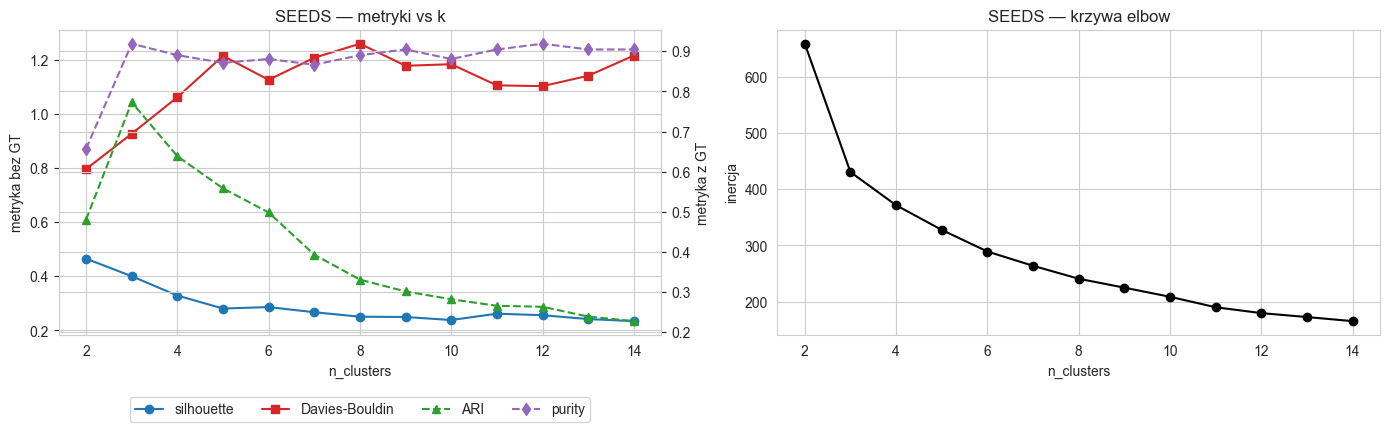

interactive(children=(IntSlider(value=3, continuous_update=False, description='k:', max=14, min=2), Output()),…

GLASS — sweep n_clusters:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,inertia
k,,,,,,,
2,2,0,0.4475,1.3783,0.1930,0.4720,1526.2794
3,3,0,0.3672,1.3602,0.1889,0.4766,1240.5858
4,4,0,0.3910,1.0722,0.1987,0.4860,1036.5917
5,5,0,0.3219,1.0557,0.2398,0.5607,888.3197
6,6,0,0.3213,0.9901,0.1719,0.5561,766.5659
7,7,0,0.3375,1.0354,0.1793,0.5514,690.7538
8,8,0,0.3421,0.9307,0.2009,0.5794,631.1724
9,9,0,0.3419,1.0956,0.1688,0.5841,586.5241
10,10,0,0.3562,0.9513,0.2046,0.6168,521.1382


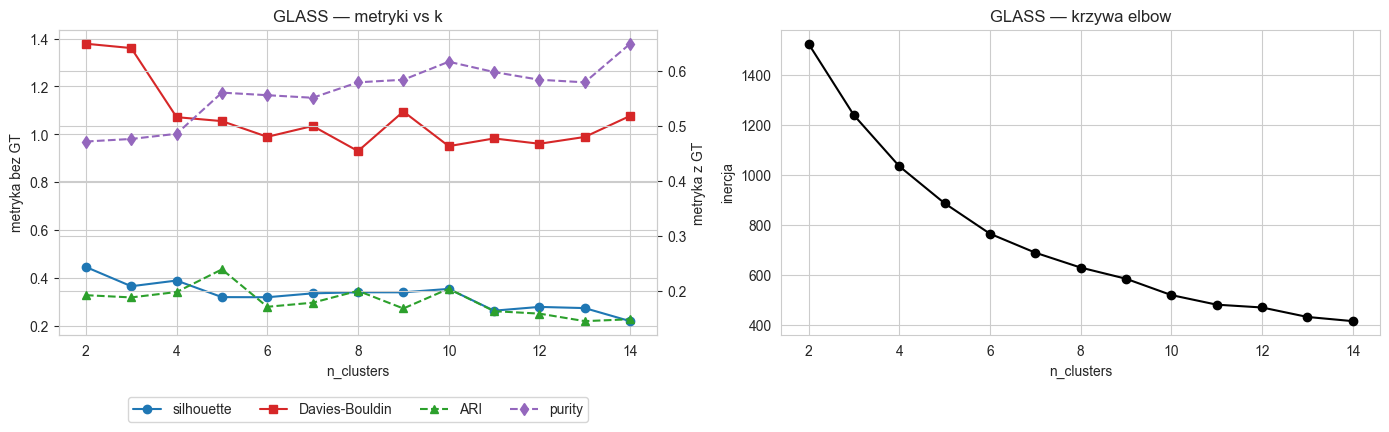

interactive(children=(IntSlider(value=3, continuous_update=False, description='k:', max=14, min=2), Output()),…

In [ ]:
res_seeds_k, models_seeds_k = sweep_n_clusters(X_seeds, y_seeds, k_range)
res_glass_k, models_glass_k = sweep_n_clusters(X_glass, y_glass, k_range)
print('SEEDS — sweep n_clusters:'); display(res_seeds_k.round(4))
plot_k_sweep(res_seeds_k, 'SEEDS')
interactive_k_sweep(X_seeds, y_seeds, models_seeds_k, res_seeds_k, 'SEEDS')
print('GLASS — sweep n_clusters:'); display(res_glass_k.round(4))
plot_k_sweep(res_glass_k, 'GLASS')
interactive_k_sweep(X_glass, y_glass, models_glass_k, res_glass_k, 'GLASS')


### 3.2 `n_init` — liczba restartów

Powtarzamy uczenie 30 razy z różnymi `random_state`, aby pokazać jak `n_init` redukuje wariancję wyniku (k-means startuje od losowych centroidów).


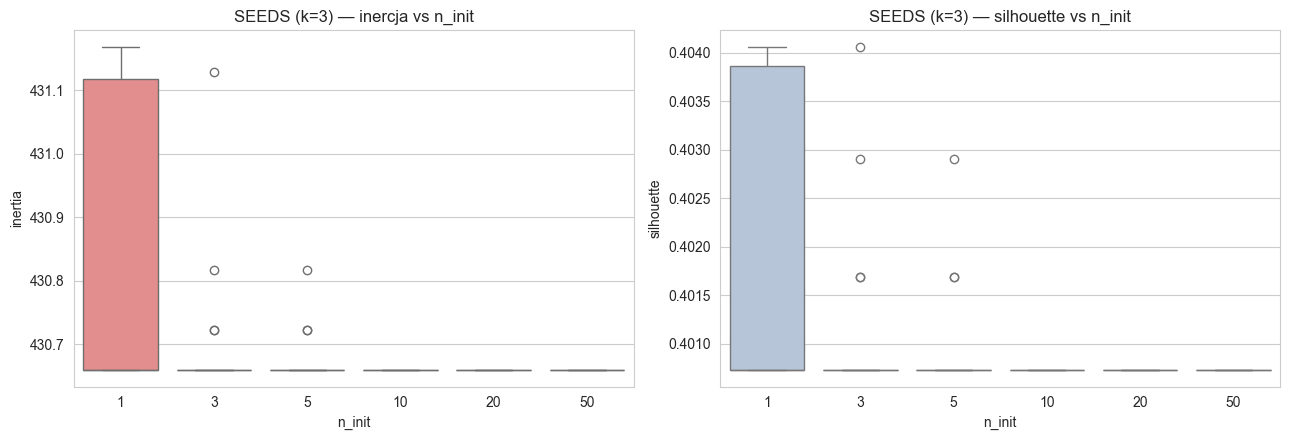

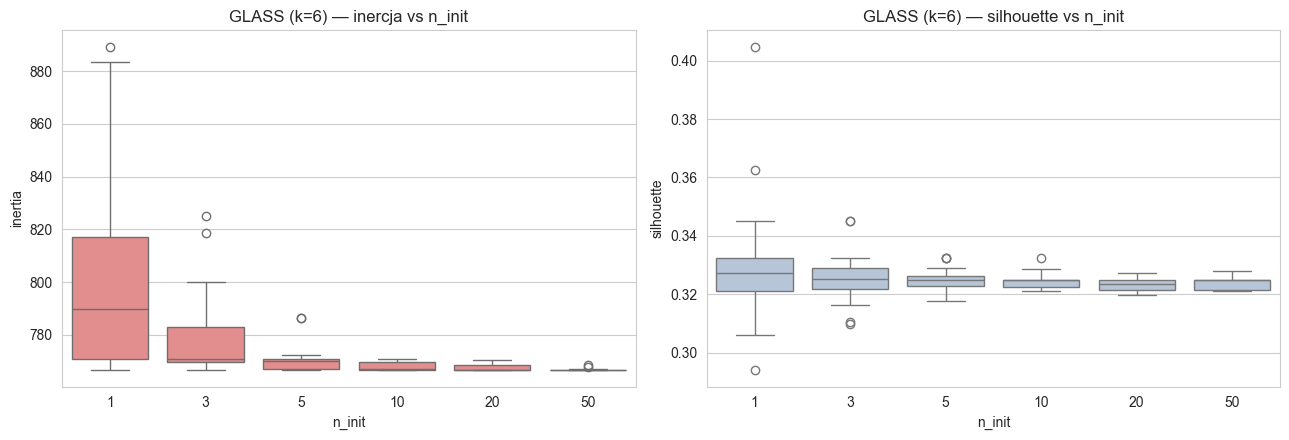

In [70]:
def sweep_n_init(X, y, k, n_init_values, n_repeats=30):
    rows = []
    for ni in n_init_values:
        for rep in range(n_repeats):
            km = KMeans(n_clusters=k, n_init=ni, max_iter=300, random_state=rep).fit(X)
            rows.append({'n_init': ni, 'rep': rep,
                         'inertia': km.inertia_,
                         'silhouette': silhouette_score(X, km.labels_)})
    return pd.DataFrame(rows)


n_init_vals = [1, 3, 5, 10, 20, 50]
df_ni_seeds = sweep_n_init(X_seeds, y_seeds, 3, n_init_vals)
df_ni_glass = sweep_n_init(X_glass, y_glass, 6, n_init_vals)  # k=6 = liczba klas w GLASS


def plot_ninit(df, title):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    sns.boxplot(data=df, x='n_init', y='inertia', ax=axes[0], color='lightcoral')
    axes[0].set_title(f'{title} — inercja vs n_init')
    sns.boxplot(data=df, x='n_init', y='silhouette', ax=axes[1], color='lightsteelblue')
    axes[1].set_title(f'{title} — silhouette vs n_init')
    plt.tight_layout(); plt.show()


plot_ninit(df_ni_seeds, 'SEEDS (k=3)')
plot_ninit(df_ni_glass, 'GLASS (k=6)')


### 3.3 `max_iter` — maksymalna liczba iteracji


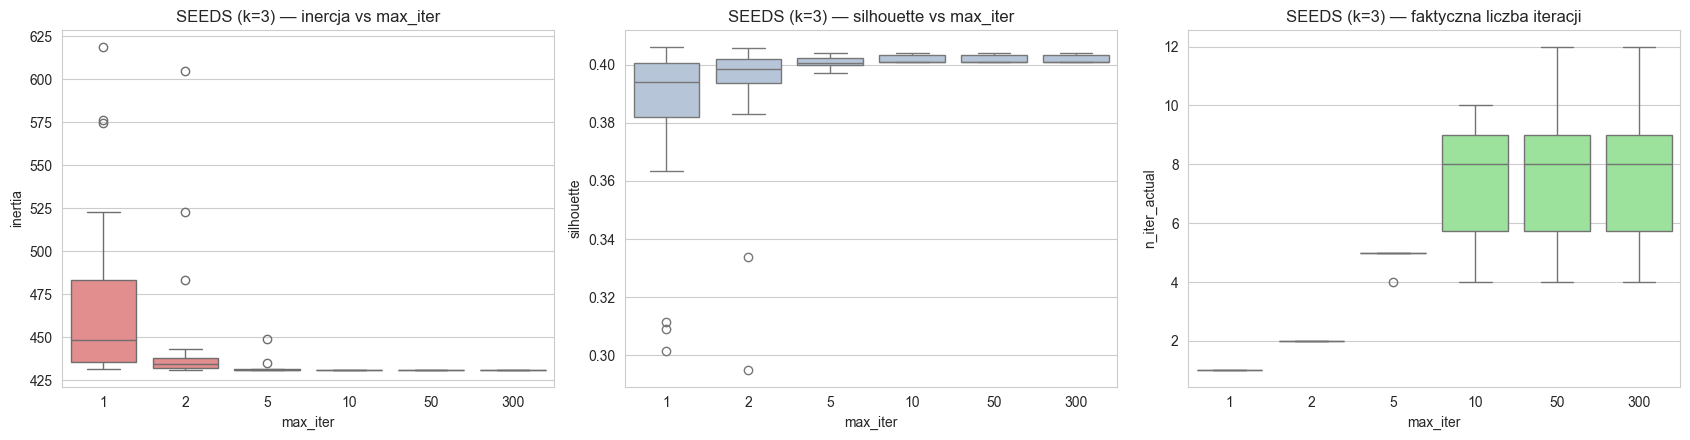

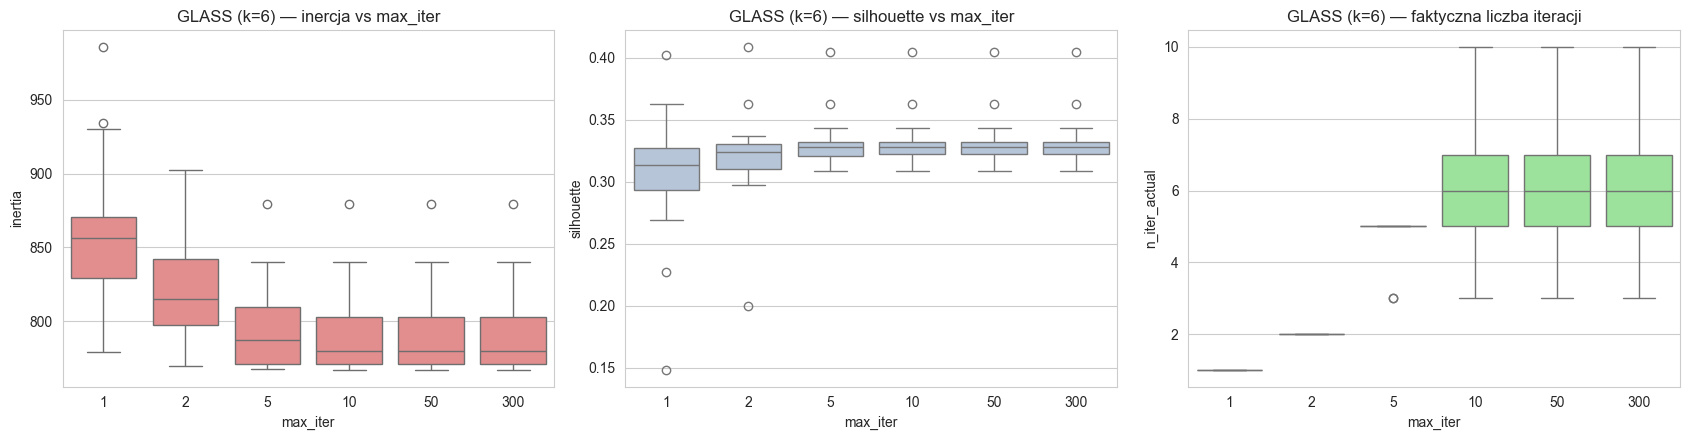

Mediana faktycznych iteracji (n_init=1):
  SEEDS: {1: 1.0, 2: 2.0, 5: 5.0, 10: 8.0, 50: 8.0, 300: 8.0}
  GLASS: {1: 1.0, 2: 2.0, 5: 5.0, 10: 6.0, 50: 6.0, 300: 6.0}


In [71]:
def sweep_max_iter(X, y, k, mi_values, n_repeats=20):
    rows = []
    for mi in mi_values:
        for rep in range(n_repeats):
            km = KMeans(n_clusters=k, n_init=1, max_iter=mi, random_state=rep).fit(X)
            rows.append({'max_iter': mi, 'rep': rep,
                         'inertia': km.inertia_,
                         'silhouette': silhouette_score(X, km.labels_),
                         'n_iter_actual': km.n_iter_})
    return pd.DataFrame(rows)


mi_vals = [1, 2, 5, 10, 50, 300]
df_mi_seeds = sweep_max_iter(X_seeds, y_seeds, 3, mi_vals)
df_mi_glass = sweep_max_iter(X_glass, y_glass, 6, mi_vals)


def plot_maxiter(df, title):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    sns.boxplot(data=df, x='max_iter', y='inertia', ax=axes[0], color='lightcoral')
    axes[0].set_title(f'{title} — inercja vs max_iter')
    sns.boxplot(data=df, x='max_iter', y='silhouette', ax=axes[1], color='lightsteelblue')
    axes[1].set_title(f'{title} — silhouette vs max_iter')
    sns.boxplot(data=df, x='max_iter', y='n_iter_actual', ax=axes[2], color='lightgreen')
    axes[2].set_title(f'{title} — faktyczna liczba iteracji')
    plt.tight_layout(); plt.show()


plot_maxiter(df_mi_seeds, 'SEEDS (k=3)')
plot_maxiter(df_mi_glass, 'GLASS (k=6)')

print('Mediana faktycznych iteracji (n_init=1):')
print('  SEEDS:', df_mi_seeds.groupby('max_iter')['n_iter_actual'].median().to_dict())
print('  GLASS:', df_mi_glass.groupby('max_iter')['n_iter_actual'].median().to_dict())


### 3.5 Warunki graniczne: k=1 i k=n

In [72]:
boundary_rows = []
for k_b in [1, len(X_seeds)]:
    km_b = KMeans(n_clusters=k_b, n_init=1, random_state=0, max_iter=300).fit(X_seeds)
    m = cluster_metrics(X_seeds, y_seeds, km_b.labels_)
    m['k'] = k_b
    m['inertia'] = km_b.inertia_
    boundary_rows.append(m)

print('Warunki graniczne k-means (SEEDS):')
display(pd.DataFrame(boundary_rows).set_index('k')
        [['inertia', 'silhouette', 'davies_bouldin', 'ARI', 'purity']].round(4))


Warunki graniczne k-means (SEEDS):


,inertia,silhouette,davies_bouldin,ARI,purity
k,,,,,
1,1470.0000,NaN,NaN,0.0000,0.3333
210,0.0000,NaN,NaN,0.0000,1.0000


## 4. Wizualizacja k-means w przestrzeni PCA

Dla każdego zbioru: ground truth + 3 warianty `n_clusters` (za małe / optymalne / za duże). Tytuł zawiera silhouette i ARI.


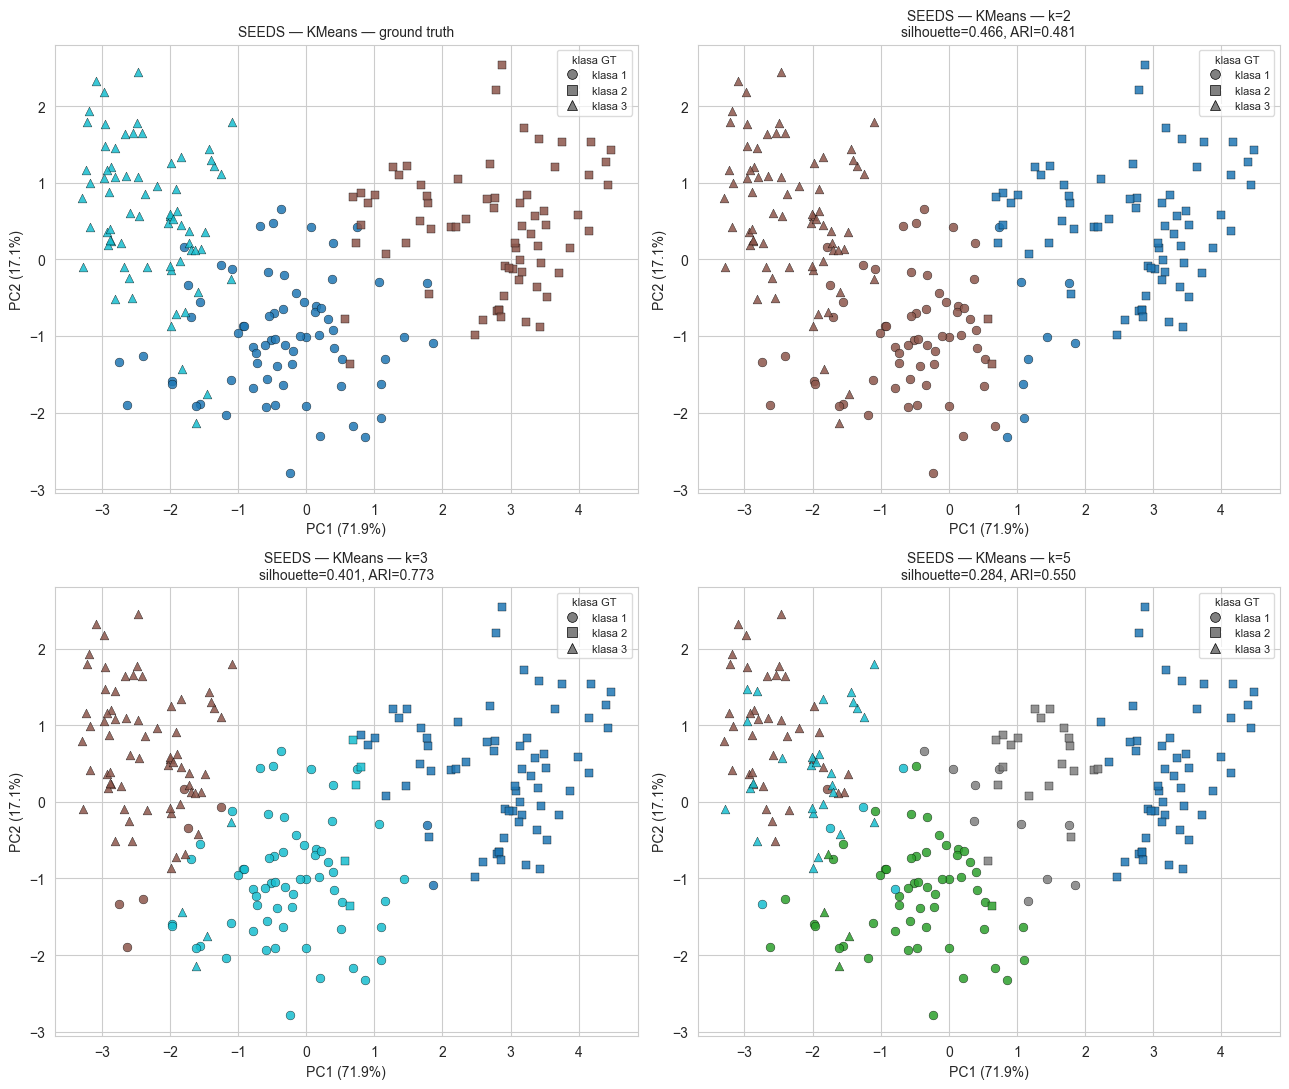

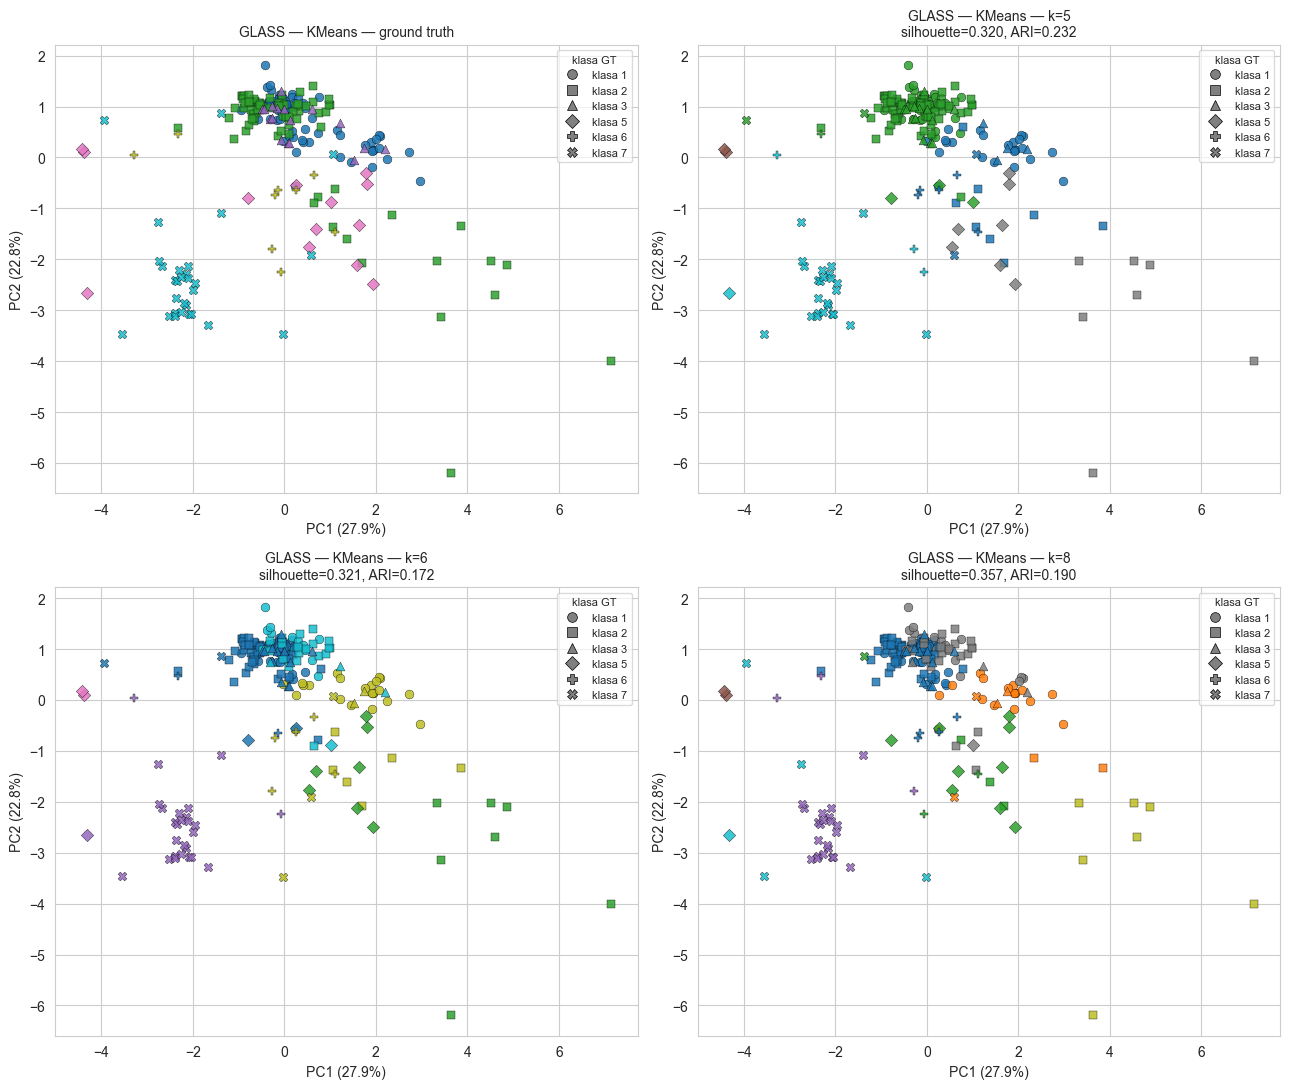

In [73]:
def four_panel_kmeans(X, y, k_best, title):
    pca = PCA(n_components=2).fit(X)
    ks = [max(2, k_best-1), k_best, k_best+2]
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    plot_clusters_pca(X, y, y, f'{title} — ground truth', ax=axes[0, 0], pca=pca)
    for ax, k in zip(axes.flatten()[1:], ks):
        km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(X)
        m = cluster_metrics(X, y, km.labels_)
        plot_clusters_pca(X, km.labels_, y,
                          f'{title} — k={k}\nsilhouette={m["silhouette"]:.3f}, ARI={m["ARI"]:.3f}',
                          ax=ax, pca=pca)
    plt.tight_layout(); plt.show()


four_panel_kmeans(X_seeds, y_seeds, k_best_seeds, 'SEEDS — KMeans')
four_panel_kmeans(X_glass, y_glass, k_best_glass, 'GLASS — KMeans')


## 5. DBSCAN — sweep hiperparametrów

Badamy `eps`, `min_samples`, `metric`. Zaczynamy od **k-distance plot** — klasycznej heurystyki doboru `eps` (knee na posortowanych odległościach do k-tego najbliższego sąsiada).


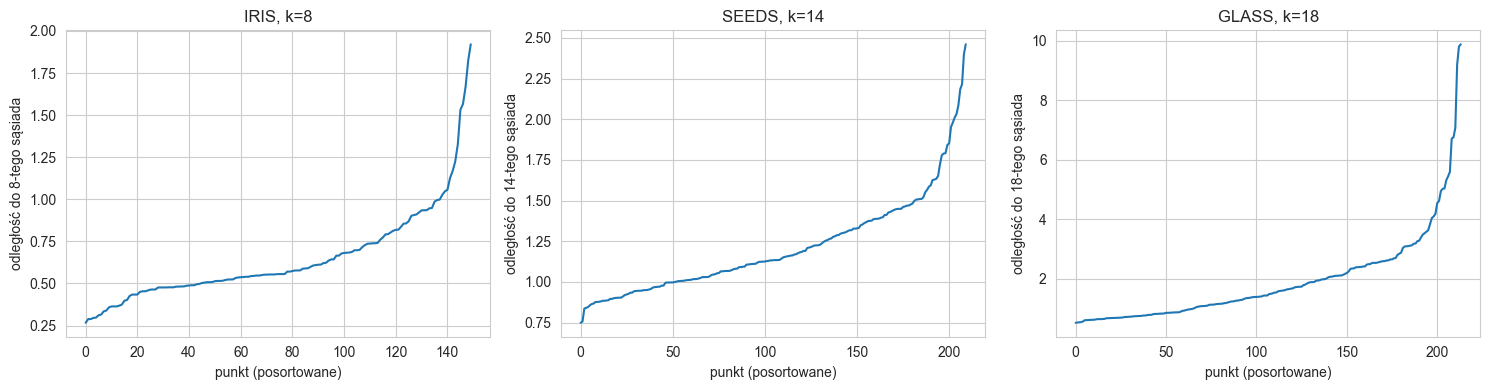

In [75]:
def kdist_plot(X, k, title, ax=None):
    nn = NearestNeighbors(n_neighbors=k).fit(X)
    d, _ = nn.kneighbors(X)
    dk = np.sort(d[:, -1])
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.plot(dk)
    ax.set_xlabel('punkt (posortowane)')
    ax.set_ylabel(f'odległość do {k}-tego sąsiada')
    ax.set_title(title)


min_samples_iris  = 2 * X_iris.shape[1]
min_samples_seeds = 2 * X_seeds.shape[1]
min_samples_glass = 2 * X_glass.shape[1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
kdist_plot(X_iris,  min_samples_iris,  f'IRIS, k={min_samples_iris}',   ax=axes[0])
kdist_plot(X_seeds, min_samples_seeds, f'SEEDS, k={min_samples_seeds}', ax=axes[1])
kdist_plot(X_glass, min_samples_glass, f'GLASS, k={min_samples_glass}', ax=axes[2])
plt.tight_layout(); plt.show()


In [76]:
db_iris = DBSCAN(eps=0.8, min_samples=4).fit(X_iris)
m = cluster_metrics(X_iris, y_iris, db_iris.labels_)
print('DBSCAN(eps=0.8, min_samples=4) na IRIS:')
display(pd.DataFrame([m]).round(4))


DBSCAN(eps=0.8, min_samples=4) na IRIS:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
0,2,4,0.5979,0.5688,0.5518,0.6800


### 5.1 Sweep `eps`


SEEDS — sweep eps:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
eps,,,,,,
0.3000,0,210,NaN,NaN,0.0000,0.3333
0.3200,0,210,NaN,NaN,0.0000,0.3333
0.3410,0,210,NaN,NaN,0.0000,0.3333
0.3610,0,210,NaN,NaN,0.0000,0.3333
0.3820,0,210,NaN,NaN,0.0000,0.3333
0.4020,0,210,NaN,NaN,0.0000,0.3333
0.4220,0,210,NaN,NaN,0.0000,0.3333
0.4430,0,210,NaN,NaN,0.0000,0.3333
0.4630,0,210,NaN,NaN,0.0000,0.3333


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/146710680.py:30: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  lines += ax.plot(df.index, df['davies_bouldin'], 's-', label='DB', color='tab:red', linestyle='--')


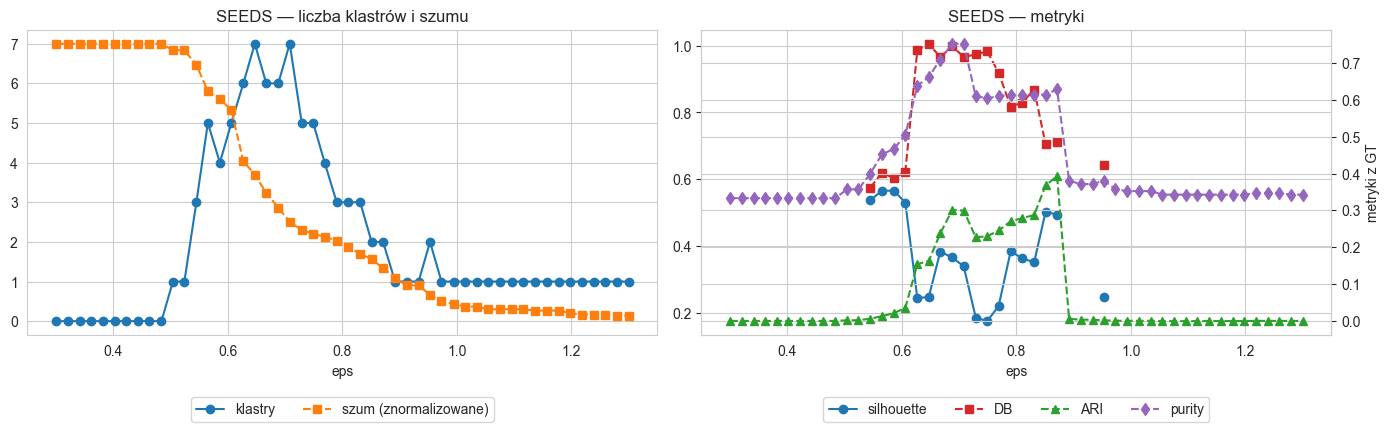

GLASS — sweep eps:


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
eps,,,,,,
0.3000,1,207,NaN,NaN,-0.0080,0.3879
0.3430,2,192,0.5270,0.6058,0.0049,0.4299
0.3860,3,181,0.4366,0.7834,-0.0143,0.4299
0.4290,5,163,0.3509,0.8367,-0.0341,0.4579
0.4710,4,160,0.2183,1.1563,-0.0355,0.4439
0.5140,1,153,NaN,NaN,-0.0215,0.3551
0.5570,1,153,NaN,NaN,-0.0215,0.3551
0.6000,2,142,0.6377,0.4144,-0.0179,0.3598
0.6430,3,134,0.2951,0.8906,-0.0110,0.3598


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/146710680.py:30: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  lines += ax.plot(df.index, df['davies_bouldin'], 's-', label='DB', color='tab:red', linestyle='--')


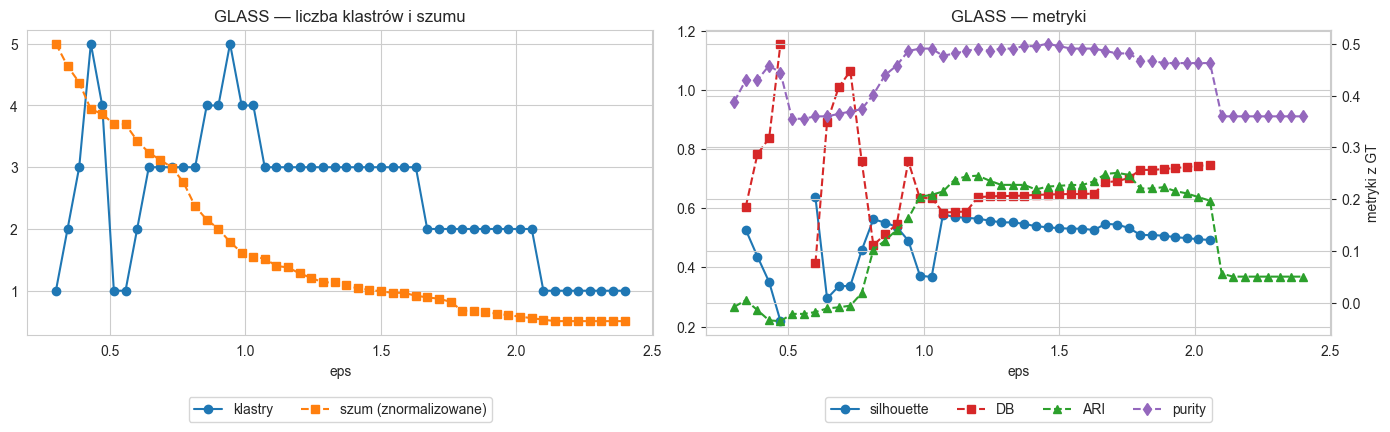

In [77]:
def sweep_eps(X, y, eps_values, min_samples=5, metric='euclidean'):
    rows = []
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        m['eps'] = eps
        rows.append(m)
    return pd.DataFrame(rows).set_index('eps')


eps_grid_seeds = np.round(np.linspace(0.3, 1.3, 50), 3) 
eps_grid_glass = np.round(np.linspace(0.3, 2.4, 50), 3)  
res_seeds_eps = sweep_eps(X_seeds, y_seeds, eps_grid_seeds)
res_glass_eps = sweep_eps(X_glass, y_glass, eps_grid_glass)


def plot_dbscan_sweep(df, x_name, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    ax = axes[0]
    ax.plot(df.index, df['n_clusters'], 'o-', label='klastry')
    ax.plot(df.index, df['n_noise'] / df['n_noise'].max() * df['n_clusters'].max(),
            's--', label='szum (znormalizowane)')
    ax.set_xlabel(x_name)
    ax.set_title(f'{title} — liczba klastrów i szumu')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=True)

    ax = axes[1]
    lines = []
    lines += ax.plot(df.index, df['silhouette'], 'o-', label='silhouette', color='tab:blue')
    lines += ax.plot(df.index, df['davies_bouldin'], 's-', label='DB', color='tab:red', linestyle='--')
    if 'ARI' in df.columns:
        ax2 = ax.twinx()
        lines += ax2.plot(df.index, df['ARI'], '^--', label='ARI', color='tab:green')
        lines += ax2.plot(df.index, df['purity'], 'd--', label='purity', color='tab:purple')
        ax2.set_ylabel('metryki z GT')
    ax.set_xlabel(x_name)
    ax.set_title(f'{title} — metryki')
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=4, frameon=True)

    plt.tight_layout()
    plt.show()

print('SEEDS — sweep eps:'); display(res_seeds_eps.round(4))
plot_dbscan_sweep(res_seeds_eps, 'eps', 'SEEDS')
print('GLASS — sweep eps:'); display(res_glass_eps.round(4))
plot_dbscan_sweep(res_glass_eps, 'eps', 'GLASS')



### 5.2 Sweep `min_samples`


eps_best:  SEEDS=0.888,  GLASS=1.212


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
min_samples,,,,,,
2,5,12,-0.2628,1.1458,0.0047,0.4095
4,1,27,NaN,NaN,0.0040,0.3762
6,3,43,0.2540,0.8737,0.3836,0.6333
8,2,64,0.5454,0.6248,0.3277,0.6286
10,3,81,0.5214,0.6687,0.4087,0.7810
12,3,95,0.5441,0.6309,0.3040,0.7190
14,3,115,0.5560,0.6032,0.1901,0.6381
16,2,170,0.5531,0.6579,0.0615,0.5095
18,0,210,NaN,NaN,0.0000,0.3333


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/146710680.py:30: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  lines += ax.plot(df.index, df['davies_bouldin'], 's-', label='DB', color='tab:red', linestyle='--')


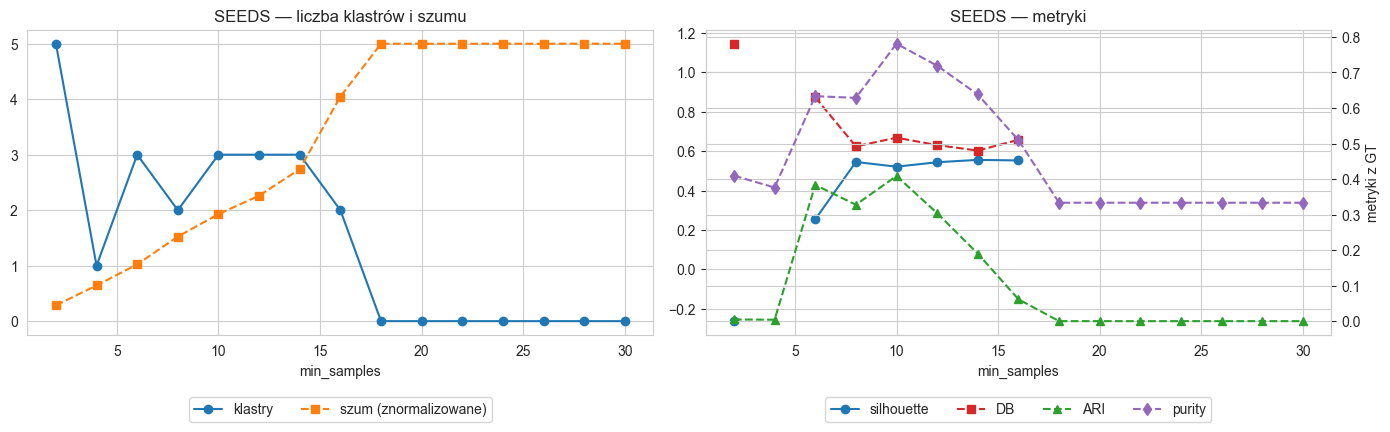

,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
min_samples,,,,,,
2,8,37,0.3436,0.5636,0.2277,0.5140
4,3,49,0.5550,0.6407,0.2301,0.4860
6,3,53,0.5648,0.6378,0.2453,0.4907
8,3,59,0.5733,0.5726,0.2231,0.4626
10,1,81,NaN,NaN,0.1867,0.4206
12,1,81,NaN,NaN,0.1867,0.4206
14,1,92,NaN,NaN,0.1394,0.3972
16,1,94,NaN,NaN,0.1304,0.3925
18,1,94,NaN,NaN,0.1304,0.3925


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/146710680.py:30: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "s-" (-> linestyle='-'). The keyword argument will take precedence.
  lines += ax.plot(df.index, df['davies_bouldin'], 's-', label='DB', color='tab:red', linestyle='--')


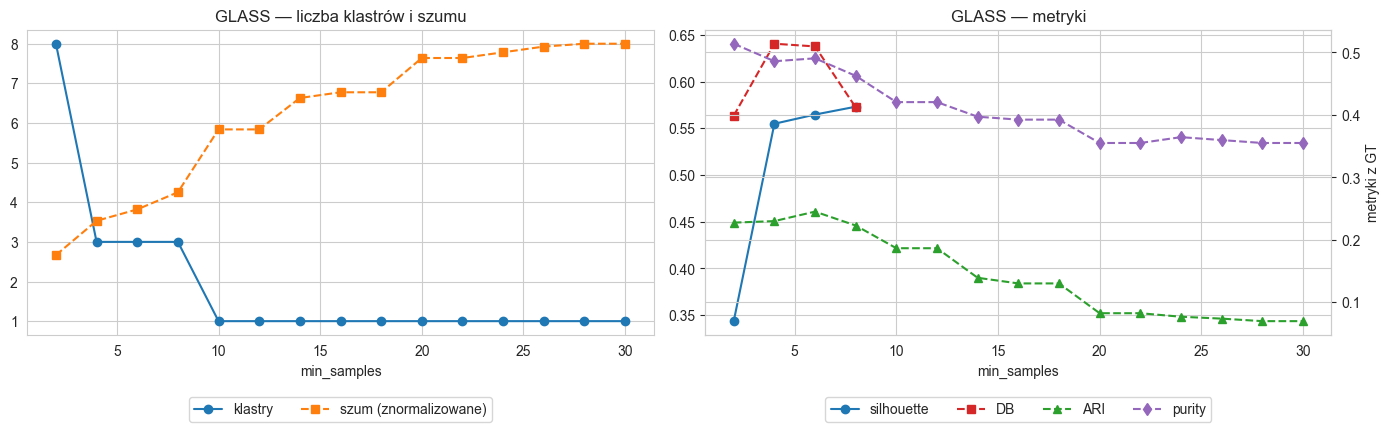

In [78]:
def sweep_min_samples(X, y, ms_values, eps, metric='euclidean'):
    rows = []
    for ms in ms_values:
        db = DBSCAN(eps=eps, min_samples=ms, metric=metric).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        m['min_samples'] = ms
        rows.append(m)
    return pd.DataFrame(rows).set_index('min_samples')


ms_vals = list(range(2, 31, 2))
eps_best_seeds = 0.888
eps_best_glass = 1.212
print(f'eps_best:  SEEDS={eps_best_seeds},  GLASS={eps_best_glass}')

res_seeds_ms = sweep_min_samples(X_seeds, y_seeds, ms_vals, eps=eps_best_seeds)
res_glass_ms = sweep_min_samples(X_glass, y_glass, ms_vals, eps=eps_best_glass)
display(res_seeds_ms.round(4))
plot_dbscan_sweep(res_seeds_ms, 'min_samples', 'SEEDS')
display(res_glass_ms.round(4))
plot_dbscan_sweep(res_glass_ms, 'min_samples', 'GLASS')


Sweeping SEEDS (eps × min_samples)...


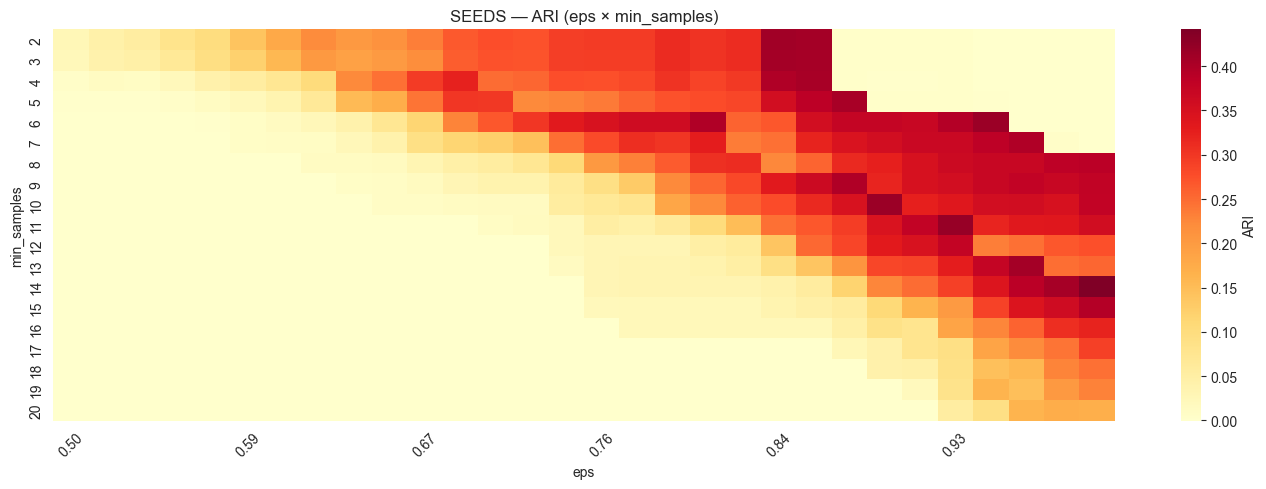

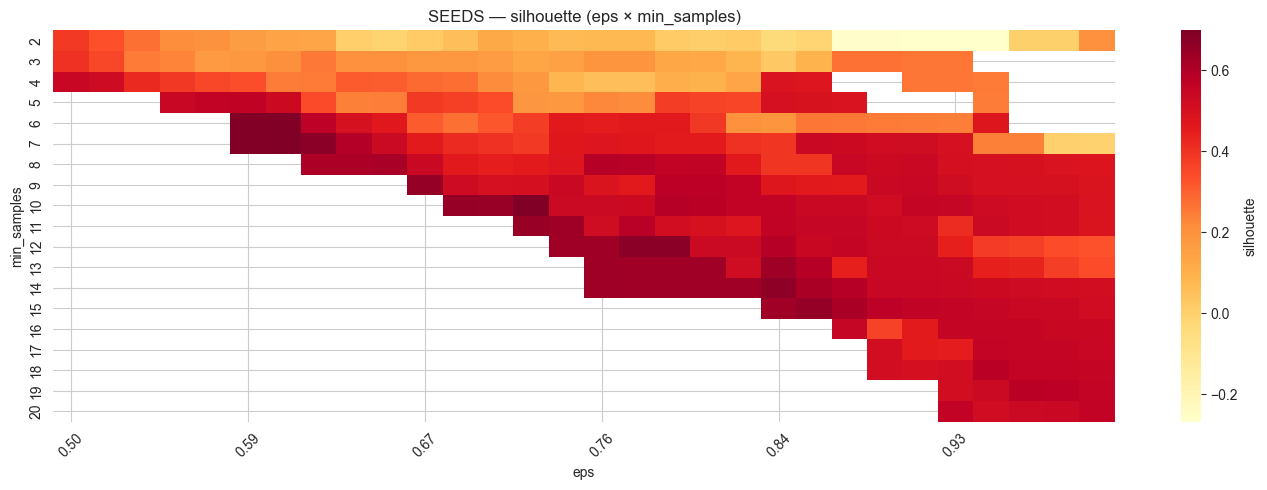

Sweeping GLASS (eps × min_samples)...


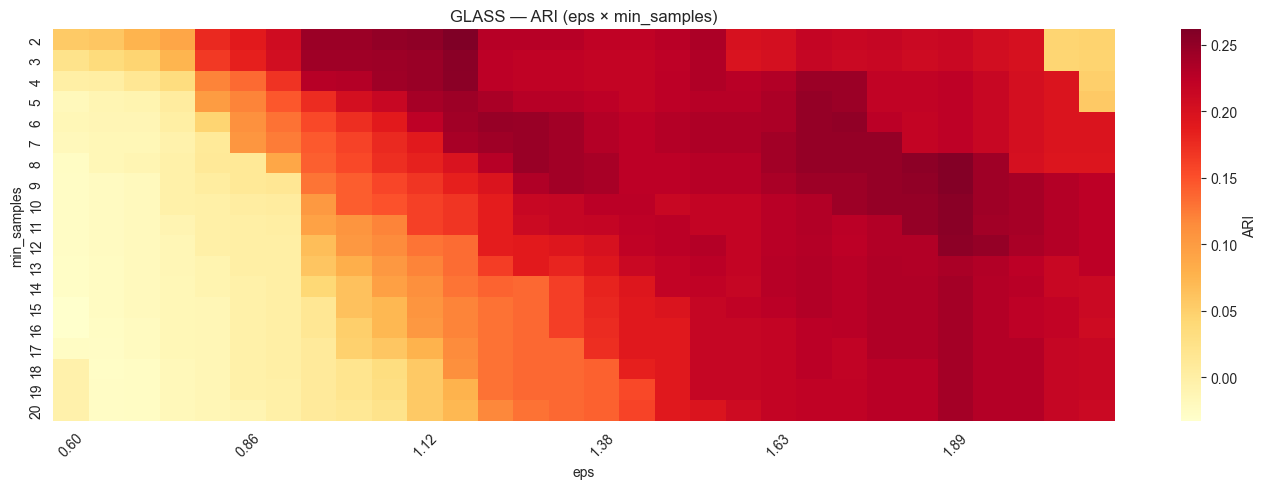

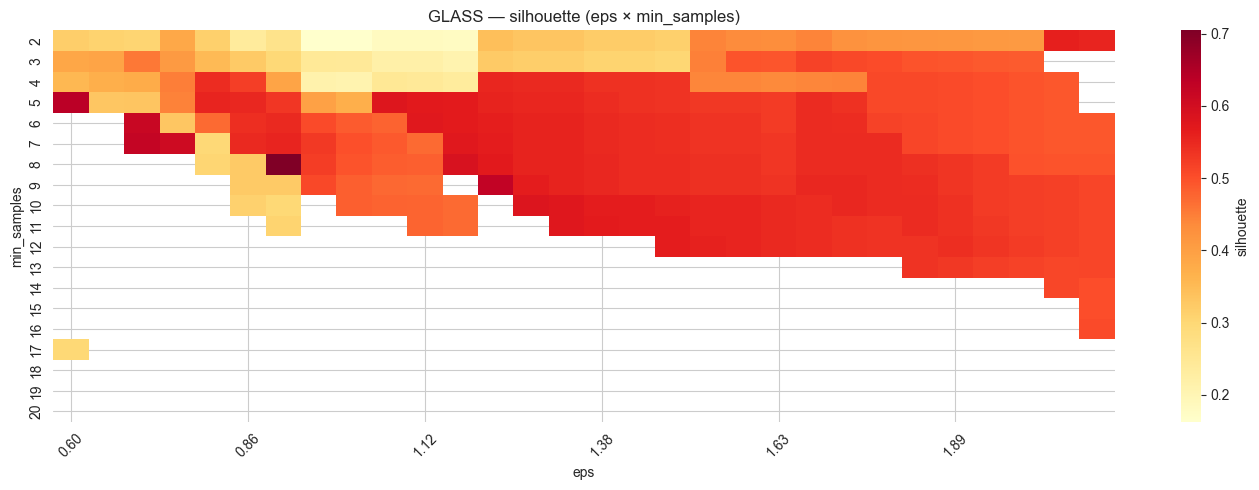

In [79]:
def sweep_eps_ms(X, y, eps_values, ms_values, metric='euclidean'):
    rows = []
    for eps in eps_values:
        for ms in ms_values:
            db = DBSCAN(eps=eps, min_samples=ms, metric=metric).fit(X)
            m = cluster_metrics(X, y, db.labels_)
            m['eps'] = eps
            m['min_samples'] = ms
            rows.append(m)
    return pd.DataFrame(rows)


def plot_heatmap_eps_ms(df, metric_col, title):
    pivot = df.pivot(index='min_samples', columns='eps', values=metric_col)
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=False,
                linewidths=0, cbar_kws={'label': metric_col})
    ax.set_title(f'{title} — {metric_col} (eps × min_samples)')
    ax.set_xlabel('eps')
    ax.set_ylabel('min_samples')
    # co 5 ticków żeby oś X była czytelna
    xticks = range(0, len(pivot.columns), 5)
    ax.set_xticks([t + 0.5 for t in xticks])
    ax.set_xticklabels([f'{pivot.columns[t]:.2f}' for t in xticks], rotation=45)
    plt.tight_layout()
    plt.show()


eps_grid_seeds = np.round(np.linspace(0.5, 1.0, 30), 3)
ms_grid = list(range(2, 21, 1))

print('Sweeping SEEDS (eps × min_samples)...')
df_seeds_2d = sweep_eps_ms(X_seeds, y_seeds, eps_grid_seeds, ms_grid)
plot_heatmap_eps_ms(df_seeds_2d, 'ARI', 'SEEDS')
plot_heatmap_eps_ms(df_seeds_2d, 'silhouette', 'SEEDS')

eps_grid_glass = np.round(np.linspace(0.6, 2.1, 30), 3)
print('Sweeping GLASS (eps × min_samples)...')
df_glass_2d = sweep_eps_ms(X_glass, y_glass, eps_grid_glass, ms_grid)
plot_heatmap_eps_ms(df_glass_2d, 'ARI', 'GLASS')
plot_heatmap_eps_ms(df_glass_2d, 'silhouette', 'GLASS')

### 5.3 Sweep `metric`


In [80]:
def tune_eps_for_metric(X, y, metric, eps_range, min_samples=5):
    best_eps, best_sil = eps_range[0], -np.inf
    for eps in eps_range:
        db = DBSCAN(eps=eps, min_samples=min_samples, metric=metric).fit(X)
        mask = db.labels_ != -1
        n_cl = len(set(db.labels_[mask])) if mask.any() else 0
        n_noise = (db.labels_ == -1).sum()
        if n_cl >= 2 and mask.sum() > n_cl and n_noise / len(X) < 0.8:
            sil = silhouette_score(X[mask], db.labels_[mask])
            if sil > best_sil:
                best_sil, best_eps = sil, eps
    return best_eps, best_sil


def sweep_metric(X, y, metrics, min_samples=5):
    rows = []
    eps_ranges = {
        'euclidean':  np.round(np.linspace(0.3, 3.0, 15), 3),
        'manhattan':  np.round(np.linspace(0.5, 6.0, 15), 3),   # ~sqrt(d) razy wiecej
        'chebyshev':  np.round(np.linspace(0.2, 2.5, 15), 3),   # <= euclidean
        'cosine':     np.round(np.linspace(0.01, 0.5, 15), 4),  # [0,1] dla znorm.
    }
    for met in metrics:
        eps_range = eps_ranges.get(met, np.round(np.linspace(0.3, 3.0, 15), 3))
        best_eps, best_sil = tune_eps_for_metric(X, y, met, eps_range, min_samples)
        db = DBSCAN(eps=best_eps, min_samples=min_samples, metric=met).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        m['metric'] = met
        m['eps_tuned'] = round(best_eps, 4)
        rows.append(m)
    return pd.DataFrame(rows).set_index('metric')


metrics_list = ['euclidean', 'manhattan', 'chebyshev', 'cosine']
print('Tuning eps per metric...')
res_seeds_met = sweep_metric(X_seeds, y_seeds, metrics_list)
res_glass_met = sweep_metric(X_glass, y_glass, metrics_list)
print('SEEDS -- metric sweep (per-metric eps):'); display(res_seeds_met.round(4))
print('GLASS -- metric sweep (per-metric eps):'); display(res_glass_met.round(4))


Tuning eps per metric...
SEEDS -- metric sweep (per-metric eps):


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,eps_tuned
metric,,,,,,,
euclidean,2,38,0.4899,0.7228,0.4048,0.6286,0.8790
manhattan,8,129,0.3406,1.0234,0.0868,0.6286,1.2860
chebyshev,2,51,0.5061,0.6804,0.3349,0.6048,0.5290
cosine,2,19,0.5059,0.7246,0.4858,0.6905,0.0800


GLASS -- metric sweep (per-metric eps):


,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity,eps_tuned
metric,,,,,,,
euclidean,3,63,0.5787,0.5852,0.2148,0.4766,1.0710
manhattan,2,45,0.5702,0.6651,0.2535,0.5000,2.8570
chebyshev,2,145,0.6558,0.4000,-0.0224,0.3598,0.3640
cosine,5,83,0.5389,0.7359,0.0864,0.5280,0.0800


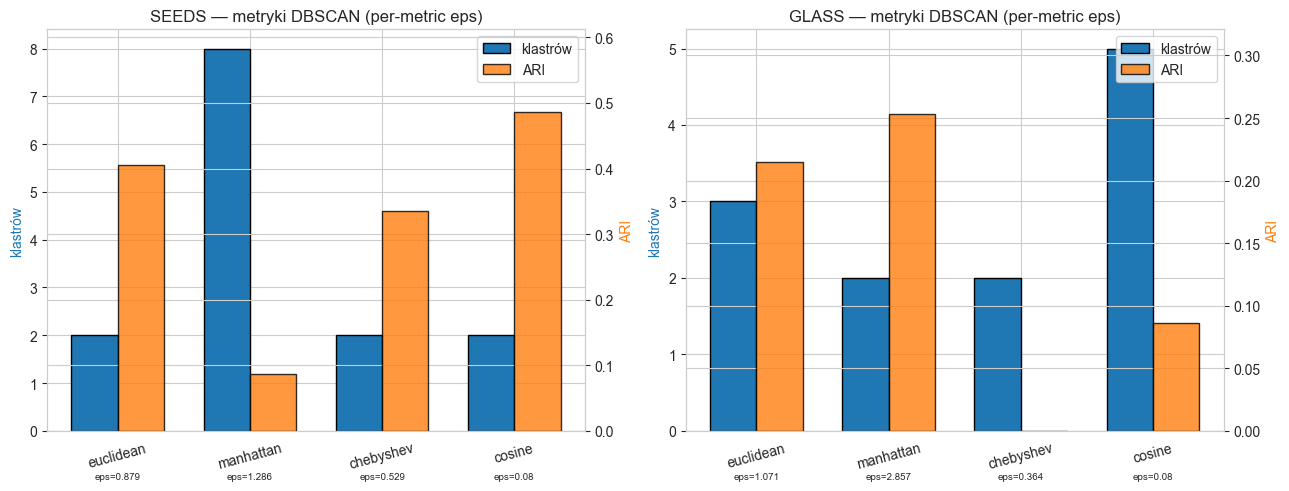

In [87]:
# Barplot: porownanie metryk odleglosci w DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (res, title) in zip(axes, [(res_seeds_met, 'SEEDS'), (res_glass_met, 'GLASS')]):
    x = np.arange(len(res))
    w = 0.35
    ax.bar(x - w/2, res['n_clusters'].fillna(0), w,
           label='klastrów', color='tab:blue', edgecolor='k')
    ax2 = ax.twinx()
    ax2.bar(x + w/2, res['ARI'].fillna(0), w,
            label='ARI', color='tab:orange', alpha=0.8, edgecolor='k')
    ax.set_xticks(x)
    ax.set_xticklabels(res.index, rotation=15)
    ax.set_ylabel('klastrów', color='tab:blue')
    ax2.set_ylim(0, ax2.get_ylim()[1] * 1.2)
    ax2.set_ylabel('ARI', color='tab:orange')
    ax.set_title(f'{title} — metryki DBSCAN (per-metric eps)')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    for j, (idx, row) in enumerate(res.iterrows()):
        ax.text(j, -0.12, f'eps={row["eps_tuned"]}', ha='center', fontsize=7,
                transform=ax.get_xaxis_transform())
plt.tight_layout()
plt.show()


## 6. Wizualizacja DBSCAN

Cztery panele: ground truth + 3 warianty `eps` (za małe / optymalne / za duże). Punkty szumu rysowane szarym X.


/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/2060107596.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],
/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/2060107596.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],


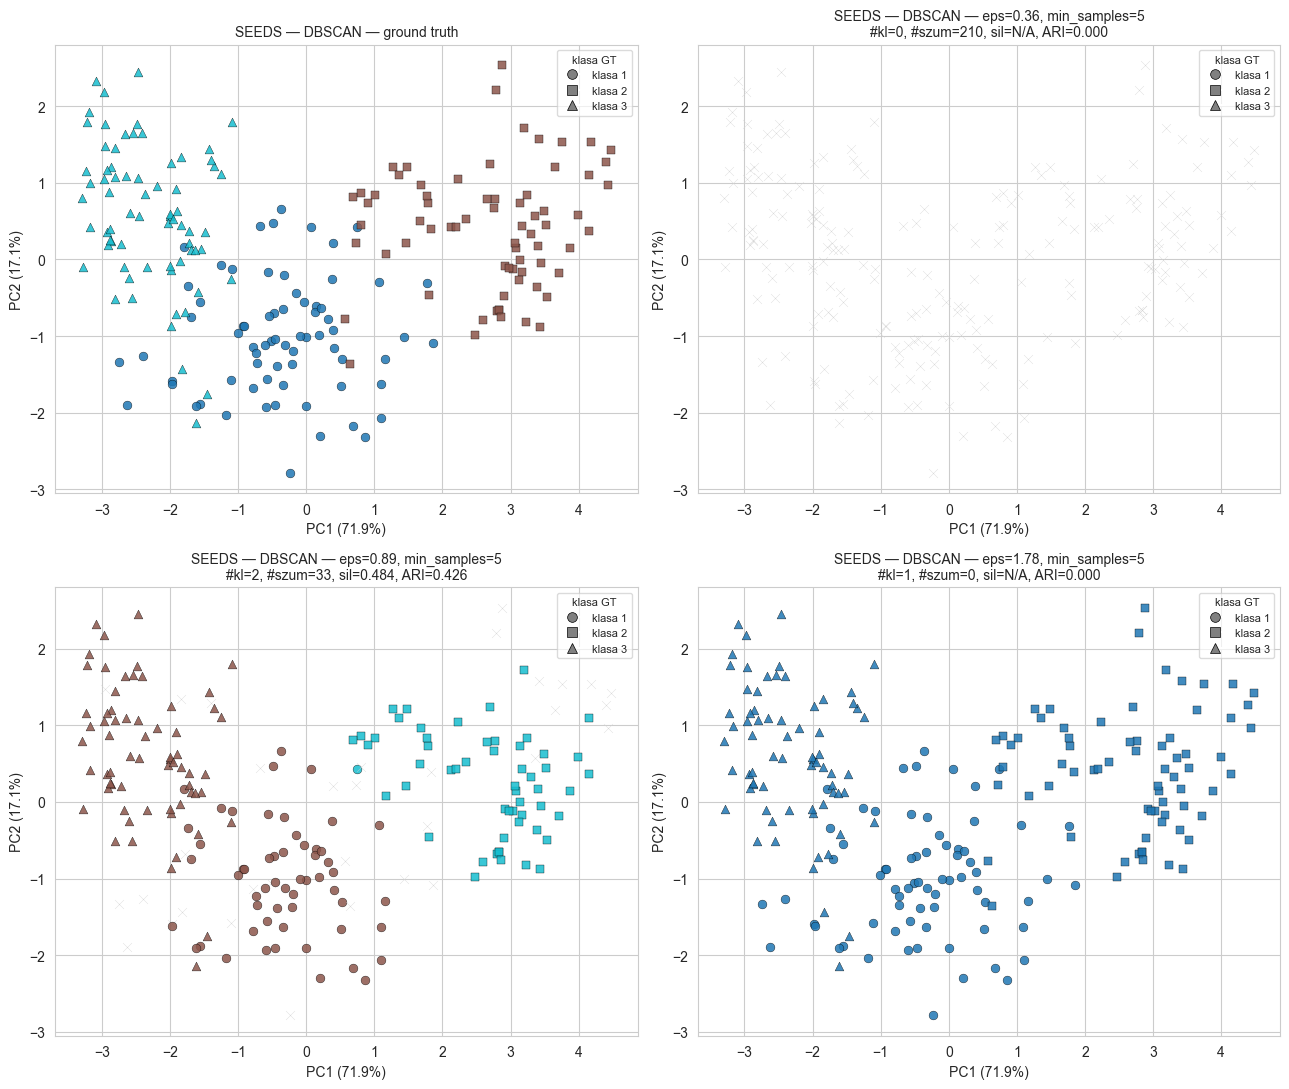

/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/2060107596.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],
/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/2060107596.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],
/var/folders/69/3bgwy7vx3g9g3hc8fwyj9pfh0000gn/T/ipykernel_99134/2060107596.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(Z[sel, 0], Z[sel, 1],


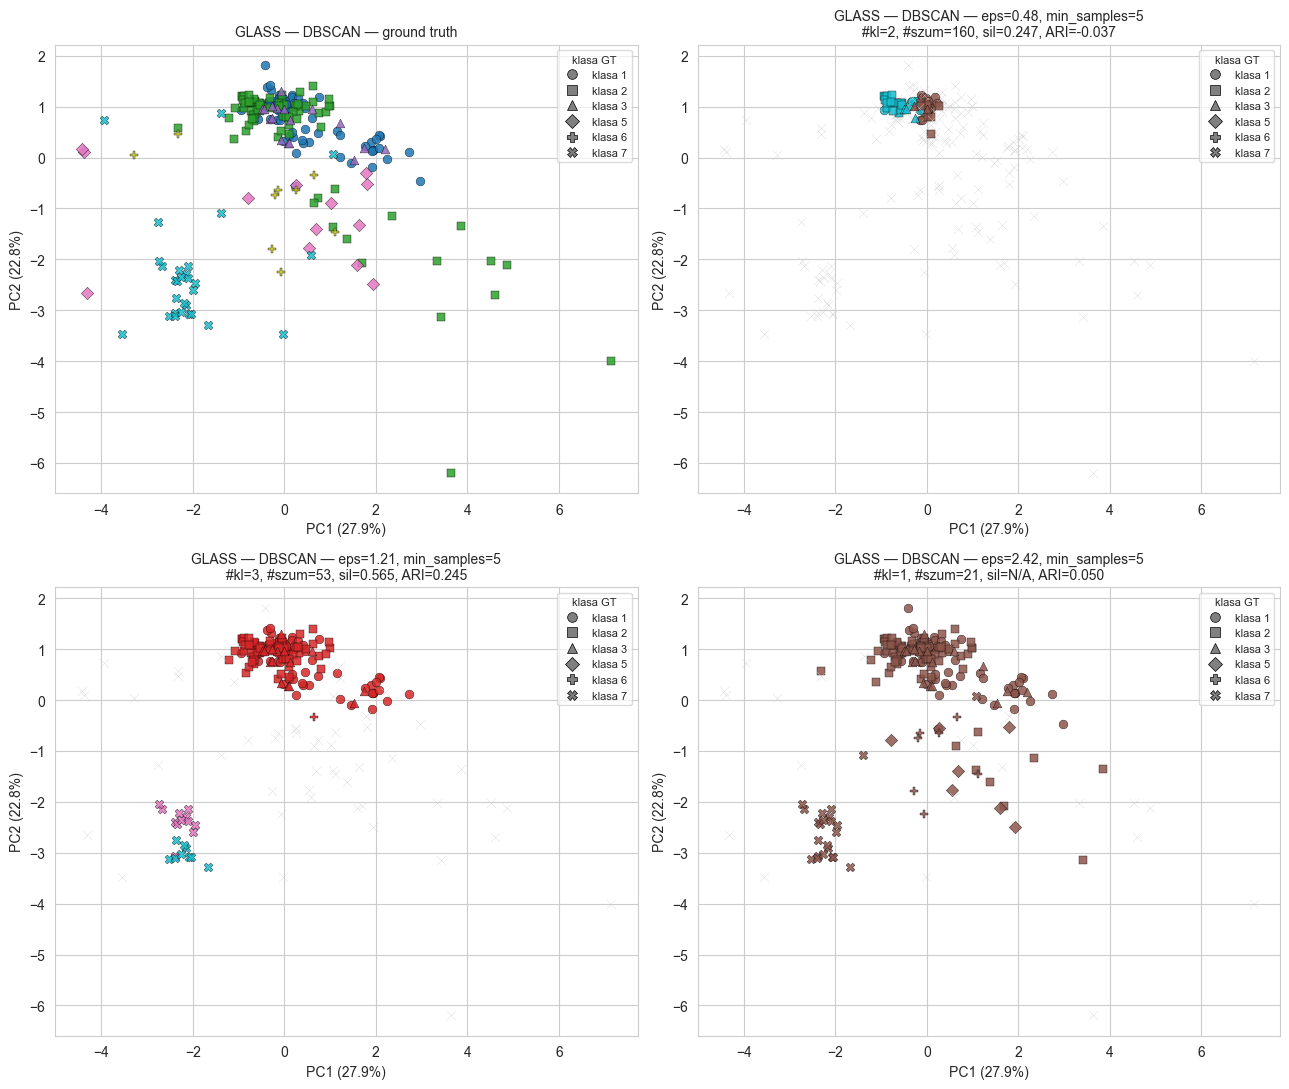

In [82]:
def four_panel_dbscan(X, y, eps_best, min_samples, title):
    pca = PCA(n_components=2).fit(X)
    eps_variants = [eps_best * 0.4, eps_best, eps_best * 2.0]
    fig, axes = plt.subplots(2, 2, figsize=(13, 11))
    plot_clusters_pca(X, y, y, f'{title} — ground truth', ax=axes[0, 0], pca=pca)
    for ax, eps in zip(axes.flatten()[1:], eps_variants):
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        m = cluster_metrics(X, y, db.labels_)
        sil = f'{m["silhouette"]:.3f}' if not np.isnan(m['silhouette']) else 'N/A'
        plot_clusters_pca(X, db.labels_, y,
                          f'{title} — eps={eps:.2f}, min_samples={min_samples}\n#kl={m["n_clusters"]}, #szum={m["n_noise"]}, sil={sil}, ARI={m["ARI"]:.3f}',
                          ax=ax, pca=pca)
    plt.tight_layout(); plt.show()


four_panel_dbscan(X_seeds, y_seeds, eps_best_seeds, 5, 'SEEDS — DBSCAN')
four_panel_dbscan(X_glass, y_glass, eps_best_glass, 5, 'GLASS — DBSCAN')


## 7. Analiza porównawcza: k-means vs DBSCAN

Porównujemy najlepsze konfiguracje obu algorytmów na obu zbiorach. Wszystkie 4 metryki w jednej tabeli.


In [84]:
rows = []
# k-means best
for name, (X, y, _), k_best in [
    ('SEEDS', DATASETS['SEEDS'], k_best_seeds),
    ('GLASS', DATASETS['GLASS'], k_best_glass),
]:
    km = KMeans(n_clusters=k_best, n_init=20, random_state=0).fit(X)
    m = cluster_metrics(X, y, km.labels_)
    m.update({'dataset': name, 'algorytm': f'KMeans(k={k_best})'})
    rows.append(m)
# DBSCAN best
for name, (X, y, _), eps_best in [
    ('SEEDS', DATASETS['SEEDS'], eps_best_seeds),
    ('GLASS', DATASETS['GLASS'], eps_best_glass),
]:
    db = DBSCAN(eps=eps_best, min_samples=5).fit(X)
    m = cluster_metrics(X, y, db.labels_)
    m.update({'dataset': name, 'algorytm': f'DBSCAN(eps={eps_best:.2f})'})
    rows.append(m)

summary = pd.DataFrame(rows).set_index(['dataset', 'algorytm'])[
    ['n_clusters', 'n_noise', 'silhouette', 'davies_bouldin', 'ARI', 'purity']
]
display(summary.round(4))


,,n_clusters,n_noise,silhouette,davies_bouldin,ARI,purity
dataset,algorytm,,,,,,
SEEDS,KMeans(k=3),3,0,0.4007,0.9279,0.7733,0.9190
GLASS,KMeans(k=6),6,0,0.3213,0.9901,0.1719,0.5561
SEEDS,DBSCAN(eps=0.89),2,33,0.4843,0.7333,0.4261,0.6429
GLASS,DBSCAN(eps=1.21),3,53,0.5648,0.6378,0.2453,0.4907


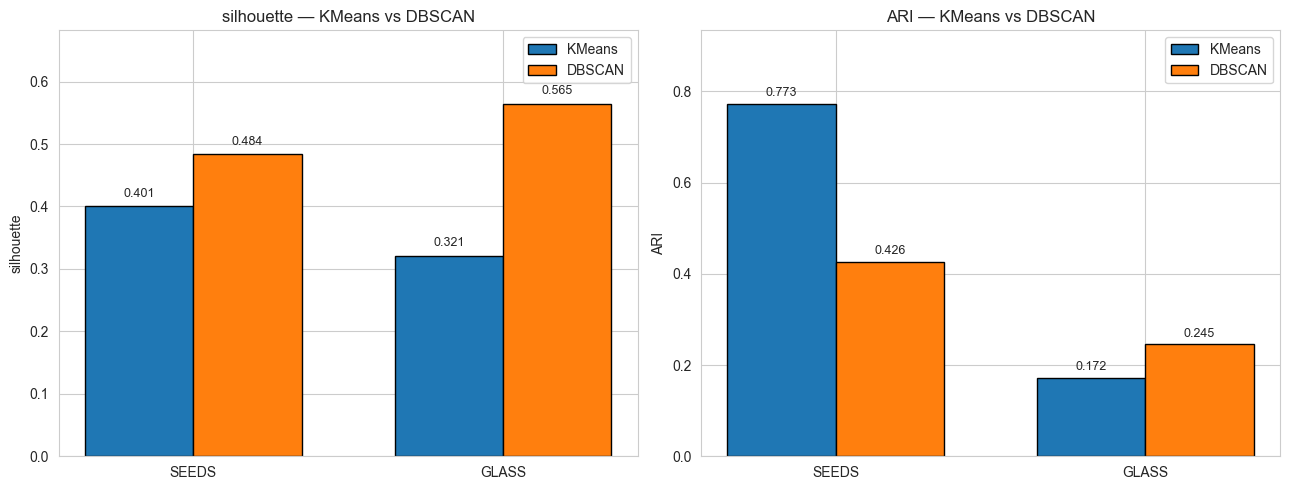

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

datasets = ['SEEDS', 'GLASS']
x = np.arange(len(datasets))
w = 0.35

algo_seeds_km = f'KMeans(k={k_best_seeds})'
algo_glass_km = f'KMeans(k={k_best_glass})'
algo_seeds_db = f'DBSCAN(eps={eps_best_seeds:.2f})'
algo_glass_db = f'DBSCAN(eps={eps_best_glass:.2f})'

pairs = [
    (algo_seeds_km, algo_glass_km, 'KMeans'),
    (algo_seeds_db, algo_glass_db, 'DBSCAN'),
]

for ax, met in zip(axes, ['silhouette', 'ARI']):
    for i, (algo_s, algo_g, label) in enumerate(pairs):
        vals = [
            summary.loc[('SEEDS', algo_s), met],
            summary.loc[('GLASS', algo_g), met],
        ]
        bars = ax.bar(x + i * w - w/2, vals, w, label=label, edgecolor='k')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_ylabel(met)
    ax.set_title(f'{met} — KMeans vs DBSCAN')
    ax.legend()
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.tight_layout()
plt.show()

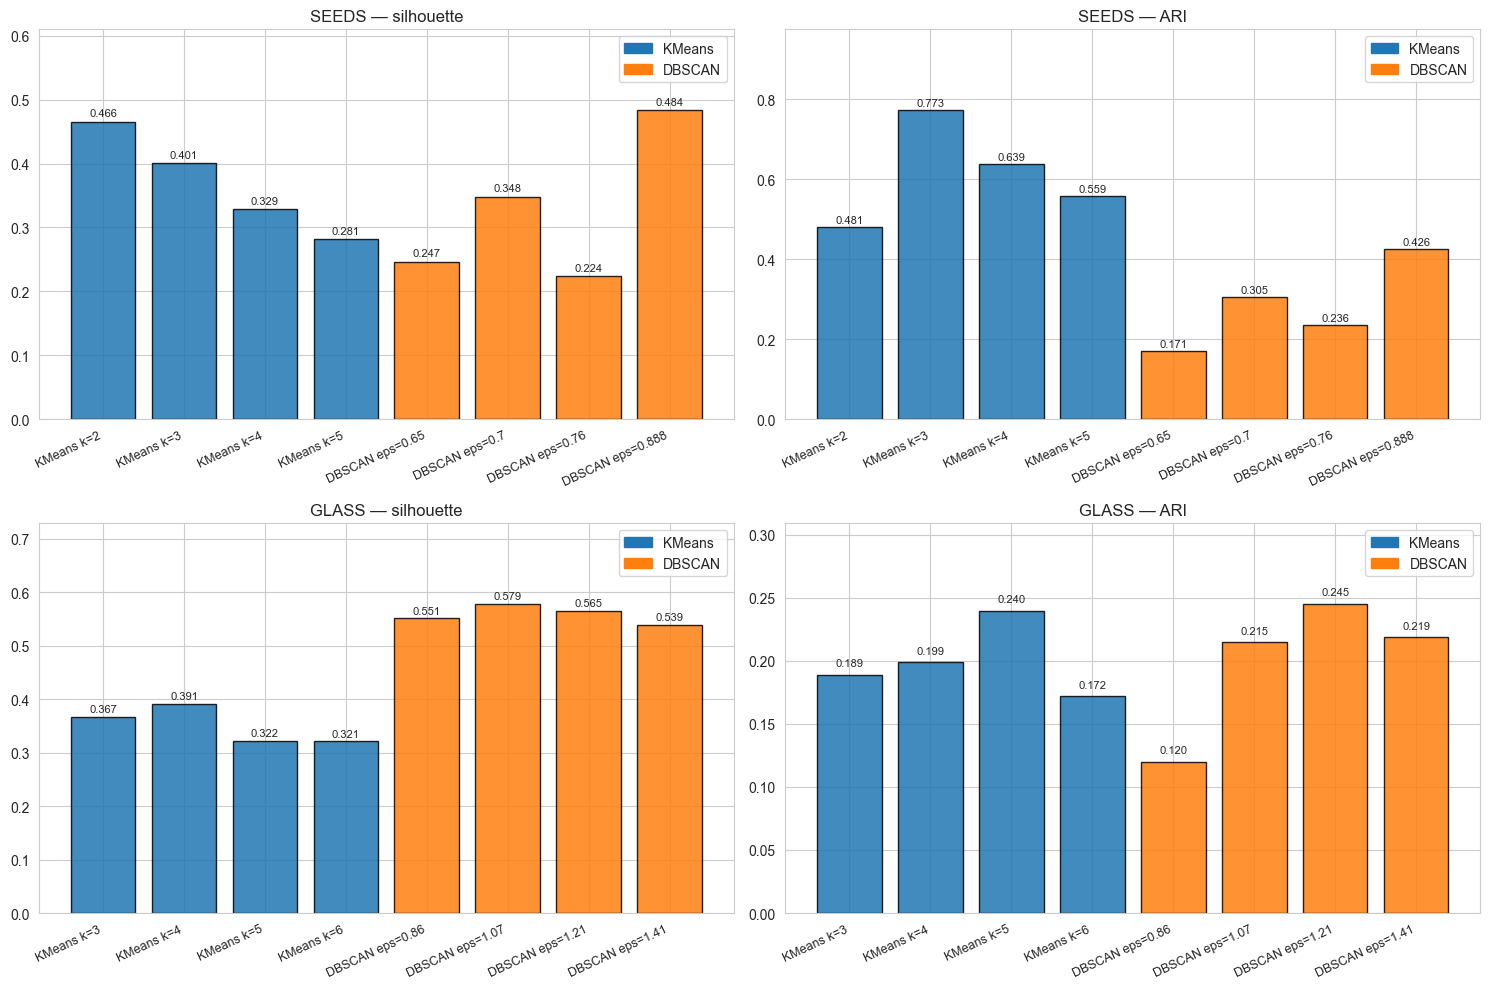

In [86]:
configs_seeds = []
for k in [2, 3, 4, 5]:
    km = models_seeds_k[k]
    m = cluster_metrics(X_seeds, y_seeds, km.labels_)
    m['algo'] = f'KMeans k={k}'
    configs_seeds.append(m)

for eps in [0.65, 0.70, 0.76, 0.888]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_seeds)
    m = cluster_metrics(X_seeds, y_seeds, db.labels_)
    m['algo'] = f'DBSCAN eps={eps}'
    configs_seeds.append(m)

configs_glass = []
for k in [3, 4, 5, 6]:
    km = models_glass_k[k]
    m = cluster_metrics(X_glass, y_glass, km.labels_)
    m['algo'] = f'KMeans k={k}'
    configs_glass.append(m)

for eps in [0.86, 1.07, 1.21, 1.41]:
    db = DBSCAN(eps=eps, min_samples=5).fit(X_glass)
    m = cluster_metrics(X_glass, y_glass, db.labels_)
    m['algo'] = f'DBSCAN eps={eps}'
    configs_glass.append(m)

df_seeds_cmp = pd.DataFrame(configs_seeds).set_index('algo')
df_glass_cmp = pd.DataFrame(configs_glass).set_index('algo')

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row, (df_cmp, title) in enumerate([(df_seeds_cmp, 'SEEDS'), (df_glass_cmp, 'GLASS')]):
    x = np.arange(len(df_cmp))
    colors = ['tab:blue' if 'KMeans' in idx else 'tab:orange' for idx in df_cmp.index]

    for col, met in enumerate(['silhouette', 'ARI']):
        ax = axes[row, col]
        bars = ax.bar(x, df_cmp[met].fillna(0), color=colors, edgecolor='k', alpha=0.85)
        for bar, val in zip(bars, df_cmp[met].fillna(0)):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(df_cmp.index, rotation=25, ha='right', fontsize=9)
        ax.set_title(f'{title} — {met}')
        ax.set_ylim(0, ax.get_ylim()[1] * 1.2)
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='tab:blue', label='KMeans'),
            Patch(color='tab:orange', label='DBSCAN'),
        ])

plt.tight_layout()
plt.show()